In [11]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"
DATABASE = "simplekg"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

COUNT_QUERY = """
RETURN
  count{ (:Document) }   AS documents,
  count{ (:Chunk) }      AS chunks,
  count{ (:__Entity__) } AS entities
"""

REL_COUNT_QUERY = """
MATCH ()-[r]->()
RETURN count(r) AS relationships
"""

with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_before = pd.DataFrame([{
    "stage": "before",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])

stats_before.to_csv("kg_stats_before.csv", index=False)
stats_before


,stage,documents,chunks,entities,relationships
0,before,242,241,674,1974


In [ ]:
with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_after = pd.DataFrame([{
    "stage": "after",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])


In [13]:
stats_before = pd.read_csv("kg_stats_before.csv")
stats_all = pd.concat([stats_before, stats_after], ignore_index=True)
stats_all


,stage,documents,chunks,entities,relationships
0,before,242,241,674,1974
1,after,242,241,674,1974


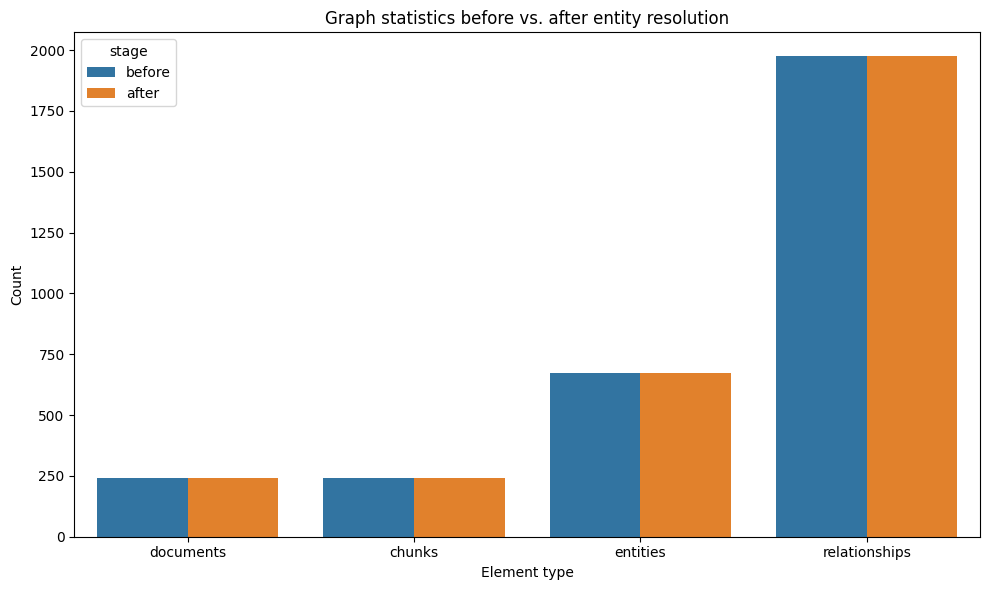

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_long = stats_all.melt(
    id_vars="stage",
    value_vars=["documents", "chunks", "entities", "relationships"],
    var_name="type",
    value_name="count",
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=stats_long,
    x="type",
    y="count",
    hue="stage"
)
plt.title("Graph statistics before vs. after entity resolution")
plt.xlabel("Element type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Zweite DB

In [20]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"
DATABASE = "neo4j"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

COUNT_QUERY = """
RETURN
  count{ (:Document) }   AS documents,
  count{ (:Chunk) }      AS chunks,
  count{ (:__Entity__) } AS entities
"""

REL_COUNT_QUERY = """
MATCH ()-[r]->()
RETURN count(r) AS relationships
"""

with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_before_2 = pd.DataFrame([{
    "stage": "before",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])

stats_before_2.to_csv("kg_stats_before.csv", index=False)
stats_before_2


,stage,documents,chunks,entities,relationships
0,before,243,243,355,1252


In [22]:
with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_before_2 = pd.DataFrame([{
    "stage": "after",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])


In [23]:
with driver.session(database=DATABASE) as session:
    row = session.run(COUNT_QUERY).single()
    rel_row = session.run(REL_COUNT_QUERY).single()

stats_after_2 = pd.DataFrame([{
    "stage": "after",
    "documents": row["documents"],
    "chunks": row["chunks"],
    "entities": row["entities"],
    "relationships": rel_row["relationships"],
}])


In [25]:
stats_before_2 = pd.read_csv("kg_stats_before.csv")
stats_all_2 = pd.concat([stats_before_2, stats_after_2], ignore_index=True)
stats_all_2


,stage,documents,chunks,entities,relationships
0,before,243,243,355,1252
1,after,243,243,355,1252


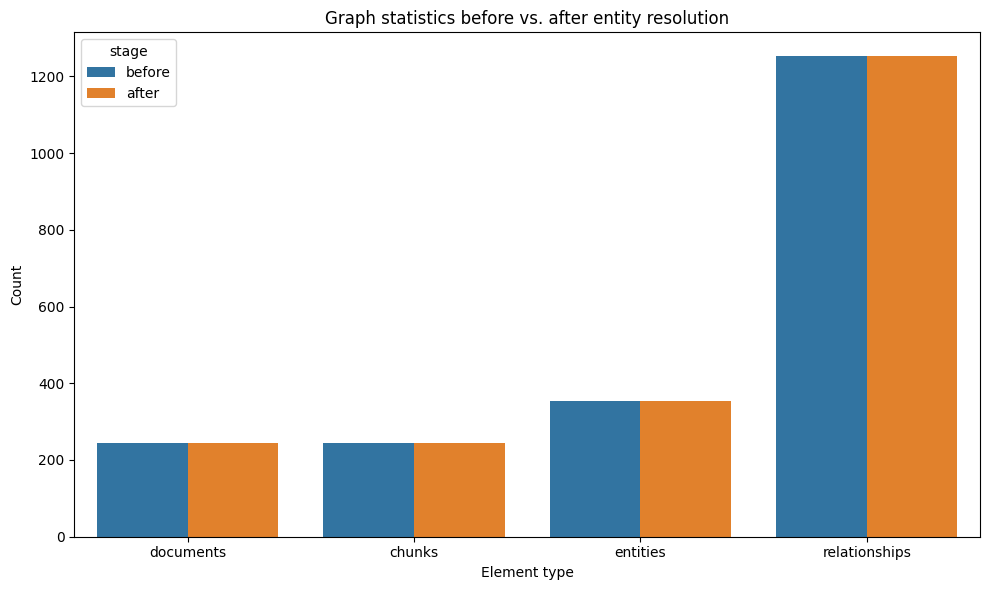

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_long_2 = stats_all_2.melt(
    id_vars="stage",
    value_vars=["documents", "chunks", "entities", "relationships"],
    var_name="type",
    value_name="count",
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=stats_long_2,
    x="type",
    y="count",
    hue="stage"
)
plt.title("Graph statistics before vs. after entity resolution")
plt.xlabel("Element type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
from langchain_neo4j import Neo4jGraph, Neo4jVector
graph = Neo4jGraph(
    url=URI,
    username=AUTH_USER,
    password=AUTH_PASSWORD,
    refresh_schema=False,
    database=DATABASE,
)

community_size = graph.query(
    """
MATCH (c:__Community__)<-[:IN_COMMUNITY*]-(e:__Entity__)
WITH c, count(distinct e) AS entities
RETURN split(c.id, '-')[0] AS level, entities
"""
)
community_size_df = pd.DataFrame.from_records(community_size)
percentiles_data = []
for level in community_size_df["level"].unique():
    subset = community_size_df[community_size_df["level"] == level]["entities"]
    num_communities = len(subset)
    percentiles = np.percentile(subset, [25, 50, 75, 90, 99])
    percentiles_data.append(
        [
            level,
            num_communities,
            percentiles[0],
            percentiles[1],
            percentiles[2],
            percentiles[3],
            percentiles[4],
            max(subset)
        ]
    )

# Create a DataFrame with the percentiles
percentiles_df = pd.DataFrame(
    percentiles_data,
    columns=[
        "Level",
        "Number of communities",
        "25th Percentile",
        "50th Percentile",
        "75th Percentile",
        "90th Percentile",
        "99th Percentile",
        "Max"
    ],
)
percentiles_df

In [ ]:
community_info = graph.query("""
MATCH (c:`__Community__`)<-[:IN_COMMUNITY*]-(e:__Entity__)
WHERE c.level IN [0,1,4]
WITH c, collect(e ) AS nodes
WHERE size(nodes) > 1
CALL apoc.path.subgraphAll(nodes[0], {
 whitelistNodes:nodes
})
YIELD relationships
RETURN c.id AS communityId, 
       [n in nodes | {id: n.id, description: n.description, type: [el in labels(n) WHERE el <> '__Entity__'][0]}] AS nodes,
       [r in relationships | {start: startNode(r).id, type: type(r), end: endNode(r).id, description: r.description}] AS rels
""")